# Reviwer 1

In [2]:
def calculate_area_in_km2(gdf):
    """
    Calculate the area of each polygon in the GeoDataFrame in square kilometers.

    Parameters:
    gdf (GeoDataFrame): GeoDataFrame with geometries.

    Returns:
    GeoDataFrame: GeoDataFrame with an added column for area in square kilometers.
    """
    if gdf.crs != 'EPSG:4326':
        gdf = gdf.to_crs('EPSG:4326')
    projected_gdf = gdf.to_crs('EPSG:3857')
    projected_gdf['area_km2'] = projected_gdf.geometry.area / 1e6
    gdf['area_km2'] = projected_gdf['area_km2']

    return gdf

In [3]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import json

# --------------------------------------------------
# Load environment variables
# --------------------------------------------------
REGION_ID = '08'  # Default region
REGION_SHAPE_DIR = '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/'
REGION_SHAPE_FILE = 'S_USA.AdministrativeRegion.shp'
IDS_REGIONS_DIR = '/net/projects/forexd/WP1/Data/CONUS/tables/'
IDS_SHAPE_FILE = 'CONUS_Region8_dissolved.shp'  # Can dynamically format region_id if needed
FIGURES_DIR = '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/figures/'

# Color mapping
COLORS_JSON = '{"wind": "#1f77b4", "defoliators": "#FF9505", "bark_beetle": "#714709"}'
COLORS = json.loads(COLORS_JSON)

# --------------------------------------------------
# Paths
# --------------------------------------------------
region_shapefile = os.path.join(REGION_SHAPE_DIR, REGION_SHAPE_FILE)
ids_file = os.path.join(IDS_REGIONS_DIR, IDS_SHAPE_FILE.format(region_id=REGION_ID))
figure_output_path = os.path.join(FIGURES_DIR, f'region_{REGION_ID}_map.png')

# --------------------------------------------------
# Load data
# --------------------------------------------------
region_gdf = gpd.read_file(region_shapefile)
region_gdf = region_gdf[region_gdf['REGION'] == REGION_ID]
ids_gdf = gpd.read_file(ids_file)
ids_gdf = calculate_area_in_km2(ids_gdf)

# Ensure CRS alignment
ids_gdf = ids_gdf.to_crs(region_gdf.crs)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot region boundary
region_gdf.explode()[0:1].plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1, label='Region boundary')


# Plot IDS points/polygons
if "disturbance_type" in ids_gdf.columns:
    for dtype, color in COLORS.items():
        subset = ids_gdf[ids_gdf['disturbance_type'] == dtype]
        subset.plot(ax=ax, color=color, label=dtype, alpha=0.7)
else:
    ids_gdf.plot(ax=ax, color='red', alpha=0.7, label='Disturbance')

ax.set_title(f"Disturbance Events in Region {REGION_ID}", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.set_axis_off()

# Save figure
os.makedirs(FIGURES_DIR, exist_ok=True)
#plt.savefig(figure_output_path, dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'calculate_area_in_km2' is not defined

In [15]:
# Largest area
max_area = ids_gdf['area_km2'].max()
max_row = ids_gdf.loc[ids_gdf['area_km2'].idxmax()]

# Smallest area
min_area = ids_gdf['area_km2'].min()
min_row = ids_gdf.loc[ids_gdf['area_km2'].idxmin()]

print(f"Largest disturbance: {max_area:.2f} km², DCA_ID: {max_row['DCA_ID']}, Index: {max_row.name}")
print(f"Smallest disturbance: {min_area:.8f} km², DCA_ID: {min_row['DCA_ID']}, Index: {min_row.name}")


Largest disturbance: 2935.01 km², DCA_ID: other_biotic, Index: 29507
Smallest disturbance: 0.00000041 km², DCA_ID: bark_beetle, Index: 24778


In [19]:
events_5km

,DCA_ID,SURVEY_YEA,REGION_ID,DAMAGE_TYP,DAMAGE_T_1,DCA_CODE,DA_Code_US,PERCENT_AF,HOST,HOST_CODE,cluster_id,geometry,area_km2
1,defoliators,2000,8,Defoliation,1,12096,2,None,None,3.0,1,"POLYGON ((-80.6151 34.0079, -80.6155 34.00939,...",4.933197
15,defoliators,2000,8,Defoliation,1,12096,2,None,None,3.0,9,"POLYGON ((-79.65231 34.30774, -79.65244 34.308...",5.849255
24,defoliators,2000,8,Defoliation,1,12089,2,None,None,-1.0,6,"POLYGON ((-79.75074 38.05186, -79.75321 38.053...",5.208530
27,defoliators,1999,8,Defoliation,1,12021,2,None,baldcypress,221.0,0,"POLYGON ((-90.65881 29.95028, -90.62161 29.952...",5.234864
41,defoliators,1999,8,Defoliation,1,12021,2,None,baldcypress,221.0,4,"POLYGON ((-91.47691 29.9979, -91.47017 29.9905...",4.880985
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65203,defoliators,2022,8,Defoliation > 75% of leaves defoliated,14,12096,2,Very Severe (>50%),None,NaN,21144,"POLYGON ((-76.48996 36.78395, -76.48553 36.800...",5.759057
65506,defoliators,2022,8,Defoliation 50-75% of leaves defoliated,13,12014,2,Severe (30-50%),None,NaN,891,"POLYGON ((-80.97296 37.10486, -80.95954 37.108...",4.136042
65604,defoliators,2022,8,Defoliation > 75% of leaves defoliated,14,12089,2,Very Severe (>50%),None,NaN,258,"POLYGON ((-78.43014 38.51142, -78.43022 38.511...",4.964679
65608,defoliators,2022,8,Defoliation 50-75% of leaves defoliated,13,12089,2,Severe (30-50%),None,NaN,25,"POLYGON ((-78.36889 39.18101, -78.37658 39.184...",5.977305


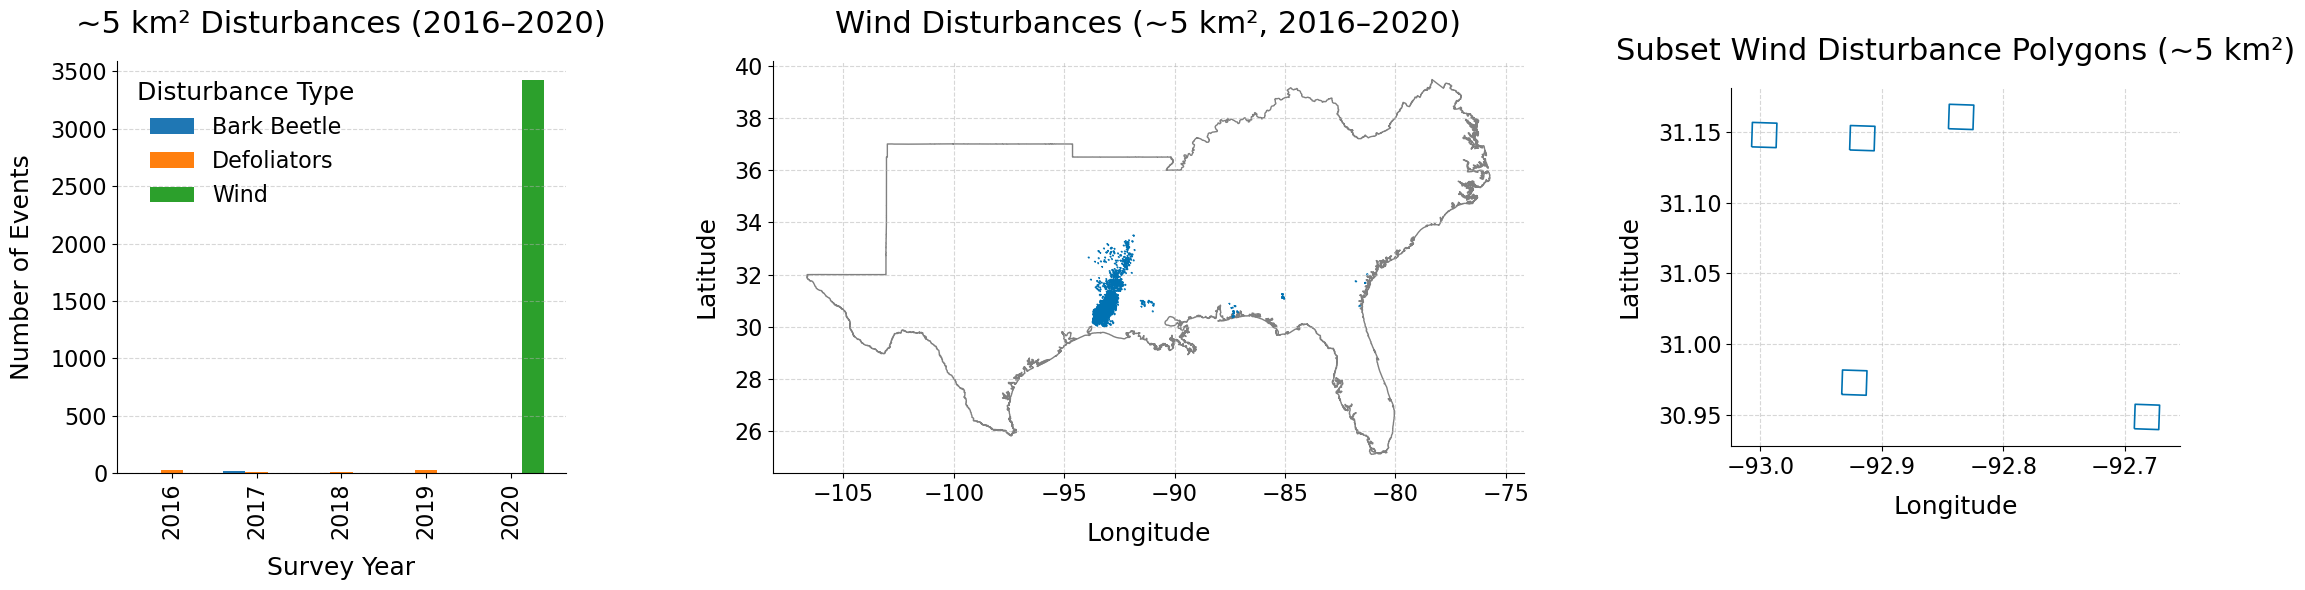

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Prepare temporal data ---
mask_5km = ids_gdf["area_km2"].between(4, 6)
events_5km = ids_gdf.loc[mask_5km].copy()
events_5km["SURVEY_YEA"] = events_5km["SURVEY_YEA"].astype(int)

selected_types = ["bark_beetle", "defoliators", "wind"]
selected_years = range(2016, 2021)

events_sel = events_5km[
    events_5km["DCA_ID"].isin(selected_types) &
    events_5km["SURVEY_YEA"].isin(selected_years)
]

# Pivot for bar plot
year_dca_sel = (
    events_sel
    .groupby(["SURVEY_YEA", "DCA_ID"])
    .size()
    .reset_index(name="Count")
)
pivot_sel = year_dca_sel.pivot(
    index="SURVEY_YEA",
    columns="DCA_ID",
    values="Count"
).fillna(0)

# Capitalize legend labels
pivot_sel.columns = [col.replace("_", " ").title() for col in pivot_sel.columns]

# --- Prepare spatial data ---
wind_5km = ids_gdf[
    ids_gdf["area_km2"].between(4, 6) &
    (ids_gdf["DCA_ID"] == "wind") &
    ids_gdf["SURVEY_YEA"].between(2016, 2020)
].copy()

# --- Create figure with equal-width subplots ---
fig, axes = plt.subplots(
    1, 3, figsize=(22, 6),
    gridspec_kw={"width_ratios": [0.5, 1, 0.5]}  # Force equal widths
)


# -----------------------------
# Left: Bar plot
# -----------------------------
pivot_sel.plot(kind="bar", ax=axes[0], width=0.8)

axes[0].set_title(
    "~5 km² Disturbances (2016–2020)",
    fontsize=22,
    pad=20
)
axes[0].set_xlabel("Survey Year", fontsize=18, labelpad=12)
axes[0].set_ylabel("Number of Events", fontsize=18, labelpad=12)
axes[0].tick_params(axis="both", which="major", labelsize=16)
axes[0].tick_params(axis="both", which="minor", labelsize=14)
axes[0].legend(title="Disturbance Type", title_fontsize=18, fontsize=16, frameon=False)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# -----------------------------
# Right: Spatial plot (wind events)
# -----------------------------
wind_5km.boundary.plot(ax=axes[1], linewidth=1.2, color="#0072B2")
region_gdf.explode()[0:1].plot(ax=axes[1], facecolor="none", edgecolor="grey", linewidth=1)

axes[1].set_title(
    "Wind Disturbances (~5 km², 2016–2020)",
    fontsize=22,
    pad=20
)
axes[1].set_xlabel("Longitude", fontsize=18, labelpad=12)
axes[1].set_ylabel("Latitude", fontsize=18, labelpad=12)
axes[1].tick_params(axis="both", which="major", labelsize=16)
axes[1].tick_params(axis="both", which="minor", labelsize=14)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

wind_5km[300:305].boundary.plot(ax=axes[2], linewidth=1.2, color="#0072B2")
axes[2].set_xlabel("Longitude", fontsize=18, labelpad=12)
axes[2].set_ylabel("Latitude", fontsize=18, labelpad=12)
axes[2].tick_params(axis="both", which="major", labelsize=16)
axes[2].tick_params(axis="both", which="minor", labelsize=14)
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].set_title(
    "Subset Wind Disturbance Polygons (~5 km²)",
    fontsize=22,
    pad=20
)

plt.tight_layout()
plt.show()


<Axes: >

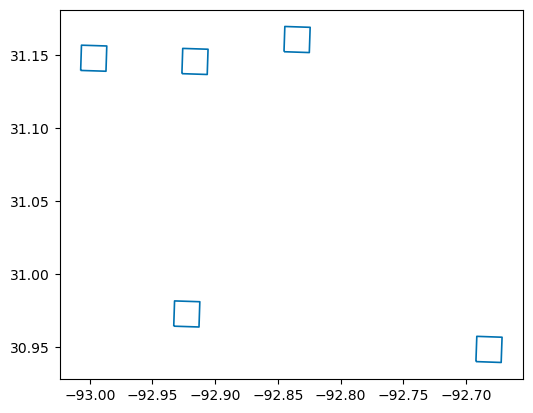

In [ ]:
wind_5km[300:305].boundary.plot(ax=axes[1], linewidth=1.2, color="#0072B2")


In [17]:
ids_gdf = ids_gdf[ids_gdf['DCA_ID'].isin(['bark_beetle', 'wind', 'defoliators'])]
ids_gdf = ids_gdf[ids_gdf['SURVEY_YEA'] >= 2016]
ids_gdf

,DCA_ID,SURVEY_YEA,REGION_ID,DAMAGE_TYP,DAMAGE_T_1,DCA_CODE,DA_Code_US,PERCENT_AF,HOST,HOST_CODE,cluster_id,geometry,area_km2
29691,bark_beetle,2016,8,Mortality,2,11030,1,Severe (30-50%),loblolly pine,131.0,5234,"POLYGON ((-91.17886 31.27813, -91.17918 31.277...",0.037331
29693,wind,2016,8,Mortality,2,50013,16,Moderate (11-29%),All tree species,9998.0,13337,"POLYGON ((-89.02927 34.93586, -89.02928 34.935...",0.324117
29694,bark_beetle,2016,8,Mortality,2,11003,1,Moderate (11-29%),None,NaN,13338,"POLYGON ((-83.58988 35.41645, -83.58993 35.416...",0.062720
29695,bark_beetle,2016,8,Mortality,2,11003,1,Moderate (11-29%),None,NaN,13339,"POLYGON ((-83.70347 35.43516, -83.70356 35.435...",0.010925
29696,bark_beetle,2016,8,Mortality,2,11003,1,Severe (30-50%),loblolly pine,131.0,13340,"POLYGON ((-83.74712 35.43908, -83.74695 35.439...",0.044889
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68911,wind,2022,8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21428,"POLYGON ((-81.77619 26.94044, -81.77583 26.942...",0.072766
68912,wind,2022,8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21428,"POLYGON ((-81.76396 26.94097, -81.7636 26.9431...",0.072767
68913,wind,2022,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),All tree species,9998.0,21465,"POLYGON ((-81.96957 27.0791, -81.96922 27.0812...",0.072944
68914,wind,2022,8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),All tree species,9998.0,21451,"POLYGON ((-81.81675 27.04737, -81.8164 27.0495...",0.072903


In [25]:
ids_gdf = calculate_area_in_km2(ids_gdf)
# Boolean mask
ids_gdf = calculate_area_in_km2(ids_gdf)

# Boolean masks
large_mask = ids_gdf['area_km2'] > 15
small_mask = ids_gdf['area_km2'] <= 15

# Counts
n_large = large_mask.sum()
n_small = small_mask.sum()
n_total = len(ids_gdf)

# Percentages
percent_large = n_large / n_total * 100
percent_small = n_small / n_total * 100

print(f"Total disturbances: {n_total}")
print(f"Number > 15 km²: {n_large} ({percent_large:.2f}%)")
print(f"Number <= 15 km²: {n_small} ({percent_small:.2f}%)")



large_gdf = ids_gdf[large_mask]
print(f"Mean area of large disturbances: {large_gdf['area_km2'].mean():.2f} km²")


Total disturbances: 27776
Number > 15 km²: 257 (0.93%)
Number <= 15 km²: 27519 (99.07%)
Mean area of large disturbances: 120.67 km²


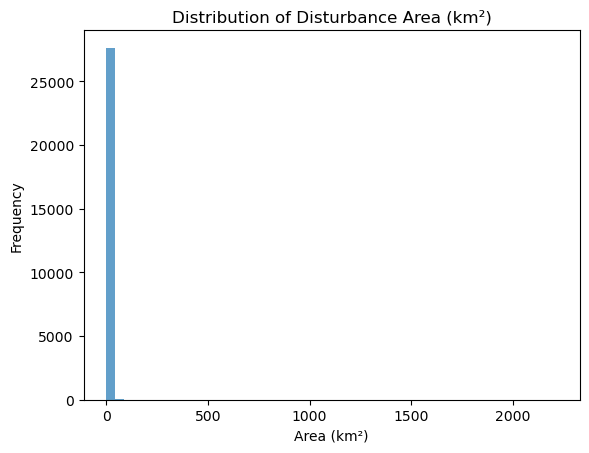

In [22]:
import matplotlib.pyplot as plt

ids_gdf['area_km2'].plot(kind='hist', bins=50, alpha=0.7)
plt.title("Distribution of Disturbance Area (km²)")
plt.xlabel("Area (km²)")
plt.ylabel("Frequency")
plt.show()



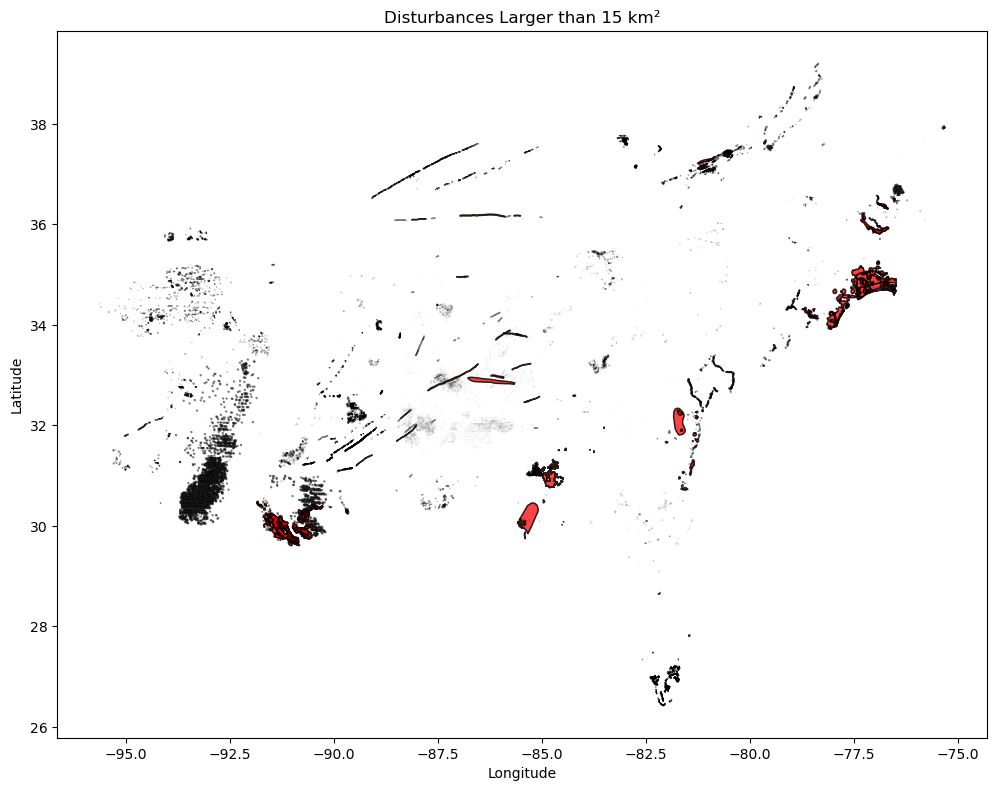

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
# Plot all for context in light grey
ids_gdf.plot(ax=ax, color='lightgrey', alpha=0.5, edgecolor='black')

# Highlight large disturbances
large_gdf.plot(ax=ax, color='red', alpha=0.7, edgecolor='black')

plt.title("Disturbances Larger than 15 km²")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [11]:
path_gdb = "/net/projects/forexd/shared/data/IDS/GeoDataBases/"
region_name = 'CONUS_Region8'
file_name = "CONUS_Rgn8"
gdf = gpd.read_file(path_gdb+f'{region_name}_AllYears/{region_name}_AllYears.gdb',layer=f'DAMAGE_AREAS_FLAT_AllYears_{file_name}')
gdf.columns

Index(['DAMAGE_AREA_ID', 'CREATED_DATE', 'MODIFIED_DATE', 'FEATURE_USER_ID',
       'OBSERVATION_USER_ID', 'REGION_ID', 'LABEL', 'HOST_CODE', 'HOST',
       'HOST_GROUP_CODE', 'HOST_GROUP', 'DCA_CODE', 'DCA_COMMON_NAME',
       'DAMAGE_TYPE_CODE', 'DAMAGE_TYPE', 'PERCENT_AFFECTED_CODE',
       'PERCENT_AFFECTED', 'PERCENT_MIN', 'PERCENT_MAX', 'PERCENT_MID',
       'NOTES', 'OBSERVATION_COUNT', 'COLLECTION_MODE', 'SNAPGRID_ROW',
       'SNAPGRID_COLUMN', 'AREA_TYPE', 'ACRES', 'STATUS', 'SURVEY_YEAR',
       'LEGACY_SEVERITY_CODE', 'LEGACY_SEVERITY', 'LEGACY_PATTERN_CODE',
       'LEGACY_PATTERN', 'LEGACY_TPA', 'LEGACY_NO_TREES',
       'LEGACY_FOREST_TYPE_CODE', 'LEGACY_FOREST_TYPE', 'GRP',
       'OBSERVATION_ID', 'IDS_DATA_SOURCE', 'DATA_SOURCE_NAME', 'US_AREA',
       'SHAPE_Length', 'SHAPE_Area', 'geometry'],
      dtype='object')

In [13]:
gdf[['LABEL', 'DCA_CODE', 'DCA_COMMON_NAME']]

,LABEL,DCA_CODE,DCA_COMMON_NAME
0,None,12096,forest tent caterpillar
1,None,12096,forest tent caterpillar
2,None,13012,periodical cicada
3,None,13012,periodical cicada
4,None,12021,fruittree leafroller
...,...,...,...
74276,Ips_mort_lob-2,11030,ips engraver beetles
74277,Ips_mort_lob-2,11030,ips engraver beetles
74278,Ips_mort_lob-1,11030,ips engraver beetles
74279,Ips_mort_lob-1,11030,ips engraver beetles


In [ ]:
# Boolean mask
gdf = calculate_area_in_km2(gdf)

# Boolean masks
large_mask = gdf['area_km2'] > 15
small_mask = gdf['area_km2'] <= 15

# Counts
n_large = large_mask.sum()
n_small = small_mask.sum()
n_total = len(gdf)

# Percentages
percent_large = n_large / n_total * 100
percent_small = n_small / n_total * 100

print(f"Total disturbances: {n_total}")
print(f"Number > 15 km²: {n_large} ({percent_large:.2f}%)")
print(f"Number <= 15 km²: {n_small} ({percent_small:.2f}%)")

# Largest area
max_area = gdf['area_km2'].max()
max_row = gdf.loc[gdf['area_km2'].idxmax()]

# Smallest area
min_area = gdf['area_km2'].min()
min_row = gdf.loc[gdf['area_km2'].idxmin()]
print(f"Largest disturbance: {max_area:.2f} km², DCA_ID: {max_row['DCA_COMMON_NAME']}, Index: {max_row.name}")
print(f"Smallest disturbance: {min_area:.8f} km², DCA_ID: {min_row['DCA_COMMON_NAME']}, Index: {min_row.name}")


large_gdf = gdf[large_mask]
print(f"Mean area of large disturbances: {large_gdf['area_km2'].mean():.2f} km²")


Total disturbances: 74281
Number > 15 km²: 1290 (1.74%)
Number <= 15 km²: 72991 (98.26%)
Largest disturbance: 62230.66 km², DCA_ID: snow-ice, Index: 5808
Smallest disturbance: 0.00000041 km², DCA_ID: southern pine beetle, Index: 24785
Mean area of large disturbances: 275.06 km²


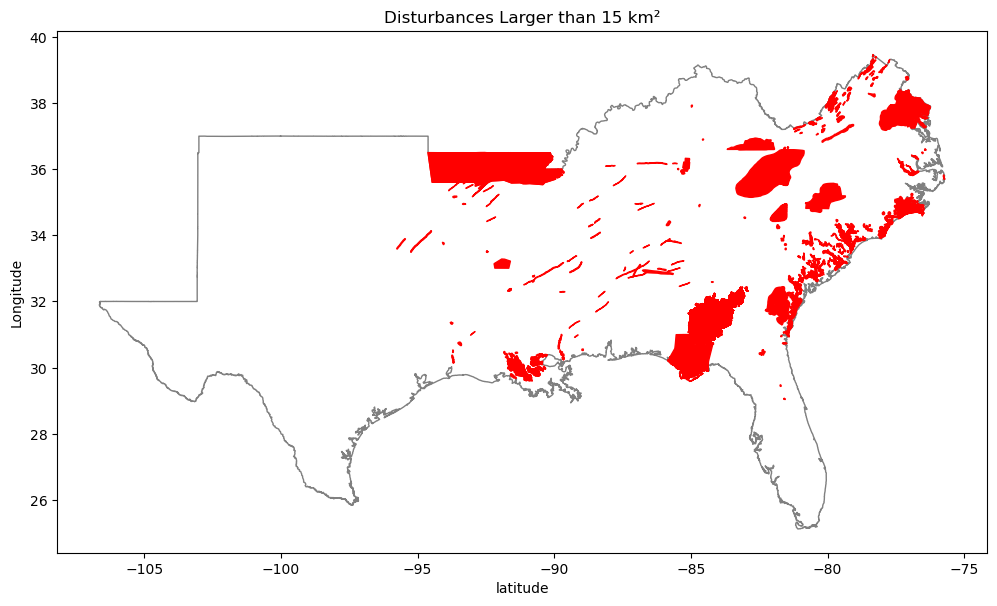

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
# Plot all for context in light grey
#gdf.plot(ax=ax, color='lightgrey', alpha=0.5, edgecolor='black')

# Plot region boundary
region_gdf.explode()[0:1].plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1, label='Region boundary')
# Highlight large disturbances
large_gdf.plot(ax=ax, color='red', alpha=1, edgecolor='red')

plt.title("Disturbances Larger than 15 km²")
plt.xlabel("latitude")
plt.ylabel("Longitude")
plt.show()


# Reviewer 2

In [4]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import json

In [5]:
ids_path = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results_tcc_30/region_08_dca_filtered_ids_usda_polygons_espg_27705.shp"
s1dm_path = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results_tcc_30/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_gdf = gpd.read_file(ids_path)
s1dm_gdf = gpd.read_file(s1dm_path)

In [6]:
# Remove unwanted disturbance types
s1dm_gdf = s1dm_gdf[~s1dm_gdf["DCA_ID"].isin(["drought","fire"])]
ids_gdf = ids_gdf[~ids_gdf["DCA_ID"].isin(["drought","fire"])]

# Dissolve by IDX_D to count unique disturbances
s1dm_unique = s1dm_gdf.dissolve(by='IDX_D', as_index=False)
ids_unique = ids_gdf.dissolve(by='IDX_D', as_index=False)

# Count unique disturbances per DCA_ID
dca_counts_s1dm = s1dm_unique['DCA_ID'].value_counts()
dca_counts_ids = ids_unique['DCA_ID'].value_counts()

# Combine into a DataFrame
counts_df = pd.DataFrame({
    'IDS': dca_counts_ids,
    'S1DM': dca_counts_s1dm
}).fillna(0)

counts_df.reset_index(inplace=True)
counts_df.rename(columns={'index': 'DCA_ID'}, inplace=True)

# Calculate reduction percentage
counts_df['Reduction (%)'] = -100 * (counts_df['IDS'] - counts_df['S1DM']) / counts_df['IDS']

# Ensure DCA_ID order
counts_df['DCA_ID'] = pd.Categorical(
    counts_df['DCA_ID'], 
    categories=['bark_beetle', 'wind', 'defoliators'], 
    ordered=True
)
counts_df_sorted = counts_df.sort_values('DCA_ID')
counts_df_sorted


,DCA_ID,IDS,S1DM,Reduction (%)
0,bark_beetle,1177,899,-23.619371
1,wind,478,469,-1.882845
2,defoliators,213,144,-32.394366


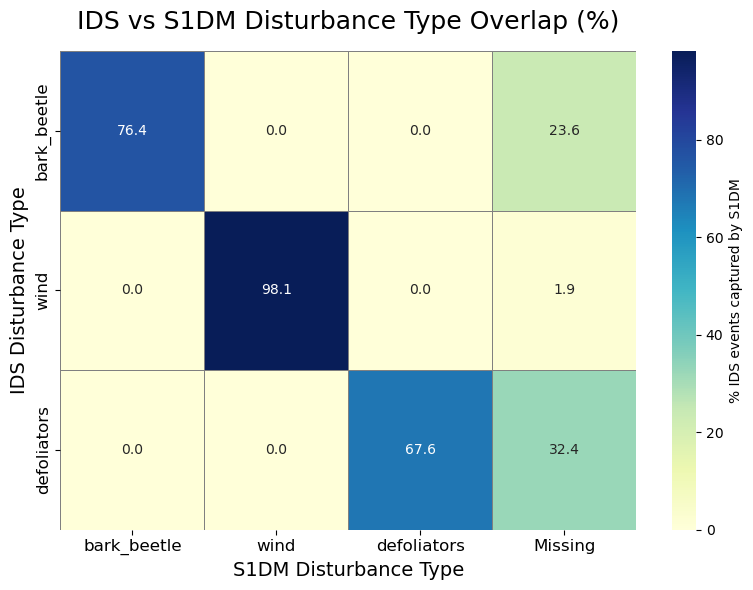

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure both are dissolved by IDX_D
ids_unique = ids_gdf.dissolve(by='IDX_D', as_index=False)
s1dm_unique = s1dm_gdf.dissolve(by='IDX_D', as_index=False)

# Merge IDS and S1DM by IDX_D to see overlap
merged = ids_unique[['IDX_D','DCA_ID']].merge(
    s1dm_unique[['IDX_D','DCA_ID']],
    on='IDX_D',
    how='left',
    suffixes=('_IDS', '_S1DM')
)

# Fill NaN (no S1DM match) with 'Missing'
merged['DCA_ID_S1DM'] = merged['DCA_ID_S1DM'].fillna('Missing')

# Create confusion-like table
conf_matrix = pd.crosstab(
    merged['DCA_ID_IDS'],
    merged['DCA_ID_S1DM'],
    normalize='index'  # % of IDS events captured
) * 100

# Optional: order rows and columns
types_order = ['bark_beetle', 'wind', 'defoliators', 'Missing']
conf_matrix = conf_matrix.reindex(index=types_order[:-1], columns=types_order)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': '% IDS events captured by S1DM'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title("IDS vs S1DM Disturbance Type Overlap (%)", fontsize=18, pad=16)
plt.xlabel("S1DM Disturbance Type", fontsize=14)
plt.ylabel("IDS Disturbance Type", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


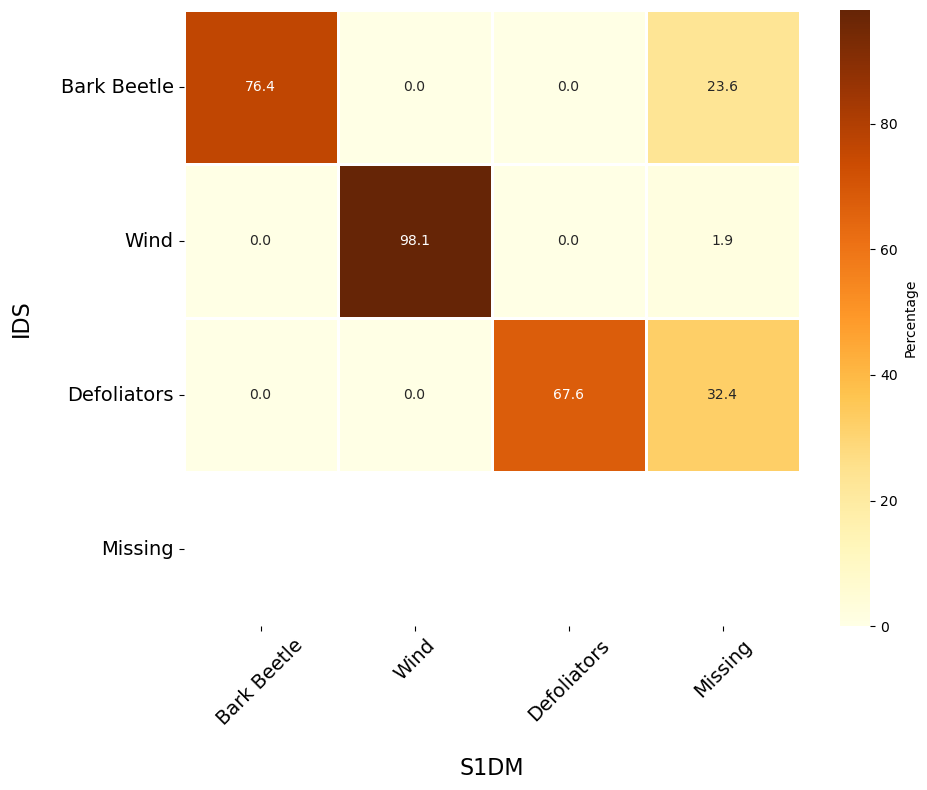

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Merge datasets as before ---
merged = ids_unique[['IDX_D','DCA_ID']].merge(
    s1dm_unique[['IDX_D','DCA_ID']],
    on='IDX_D',
    how='outer',
    suffixes=('_IDS','_S1DM')
)
merged['DCA_ID_IDS'] = merged['DCA_ID_IDS'].fillna('Missing')
merged['DCA_ID_S1DM'] = merged['DCA_ID_S1DM'].fillna('Missing')

# --- Confusion matrix ---
conf_matrix = pd.crosstab(
    merged['DCA_ID_IDS'],
    merged['DCA_ID_S1DM']
)

# --- Reorder rows and columns and relabel nicely ---
types_order = ['bark_beetle', 'wind', 'defoliators', 'Missing']
labels_pretty = ['Bark Beetle', 'Wind', 'Defoliators', 'Missing']

conf_matrix = conf_matrix.reindex(index=types_order, columns=types_order)
conf_matrix.index = labels_pretty
conf_matrix.columns = labels_pretty

# --- Normalize rows to percentage ---
conf_matrix_pct = conf_matrix.div(conf_matrix.sum(axis=1), axis=0) * 100

# --- Plot ---
plt.figure(figsize=(10,8))
sns.heatmap(
    conf_matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrBr",  # warm colors for emphasis
    linewidths=1.0,
    linecolor='white',
    cbar_kws={'label': 'Percentage', 'shrink':1},
    square=True
)

#plt.title("Confusion Matrix: IDS vs S1DM Disturbance Types (%)", fontsize=20, pad=20)
plt.xlabel("S1DM", fontsize=16, labelpad=20)
plt.ylabel("IDS", fontsize=16,labelpad=20)

plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14, rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipykernel_94058/1217326467.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_pretty, fontsize=20, fontweight='medium')


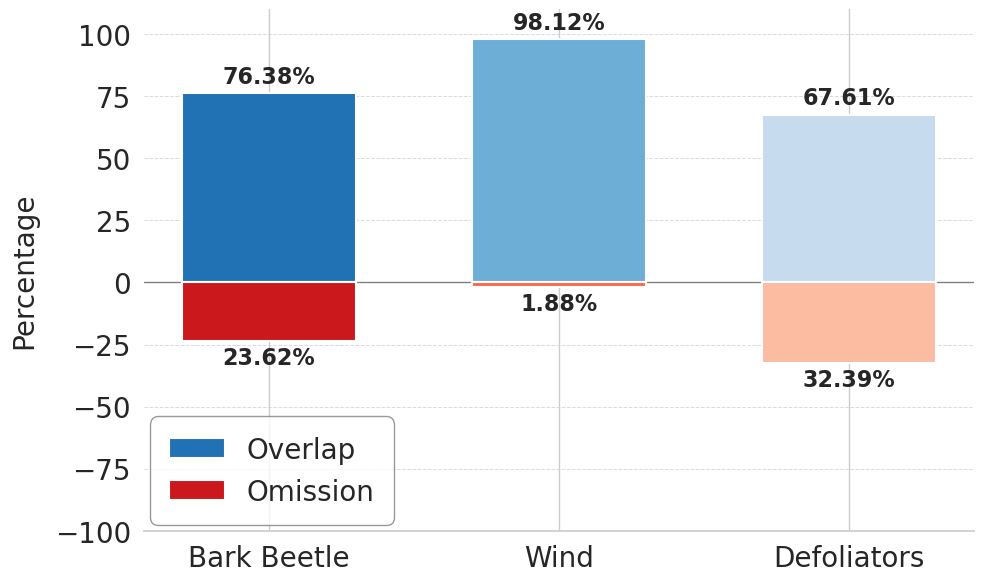

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Compute overlap and omission per disturbance type ---
types_order = ['bark_beetle', 'wind', 'defoliators']
labels_pretty = ['Bark Beetle', 'Wind', 'Defoliators']

overlap_list = []
omission_list = []

for dtype in types_order:
    subset = merged[merged['DCA_ID_IDS'] == dtype]
    total = len(subset)
    overlap = (subset['DCA_ID_S1DM'] == dtype).sum()
    omission = total - overlap
    overlap_pct = 100 * overlap / total
    omission_pct = -100 * omission / total  # negative for plotting below x-axis
    overlap_list.append(overlap_pct)
    omission_list.append(omission_pct)

# --- Plot ---
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10,6))

# Bar width and positions
bar_width = 0.6
x = np.arange(len(labels_pretty))

# Soft color palettes
overlap_colors = sns.color_palette("Blues_r", len(overlap_list))  # reversed for gradient
omission_colors = sns.color_palette("Reds_r", len(omission_list))

# Plot positive overlap bars
bars1 = ax.bar(
    x, overlap_list, 
    color=overlap_colors,
    width=bar_width, 
    edgecolor='white', 
    linewidth=1.5, 
    label="Overlap",
    zorder=3
)

# Plot negative omission bars
bars2 = ax.bar(
    x, omission_list, 
    color=omission_colors,
    width=bar_width, 
    edgecolor='white', 
    linewidth=1.5, 
    label="Omission",
    zorder=3
)

# Zero line
ax.axhline(0, color='gray', linewidth=1.0, zorder=2)

# Add annotations on bars
for i, (ov, om) in enumerate(zip(overlap_list, omission_list)):
    ax.text(i, ov + 2, f"{ov:.2f}%", ha='center', va='bottom', fontsize=16, fontweight='bold')
    ax.text(i, om - 2, f"{-om:.2f}%", ha='center', va='top', fontsize=16, fontweight='bold')

# Labels and ticks
ax.set_ylabel("Percentage", fontsize=20, labelpad=12)
ax.set_xticklabels(labels_pretty, fontsize=20, fontweight='medium')
ax.set_xticks(x)
ax.set_xticklabels(labels_pretty, fontsize=20, fontweight='medium')
ax.tick_params(axis='y', labelsize=20)

# Grid and aesthetics
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7, zorder=0)
ax.set_ylim(-100, 110)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Legend with rounded frame
legend = ax.legend(fontsize=20, frameon=True, edgecolor='gray', facecolor='white')
legend.get_frame().set_boxstyle('round,pad=0.3')

plt.tight_layout()
plt.show()


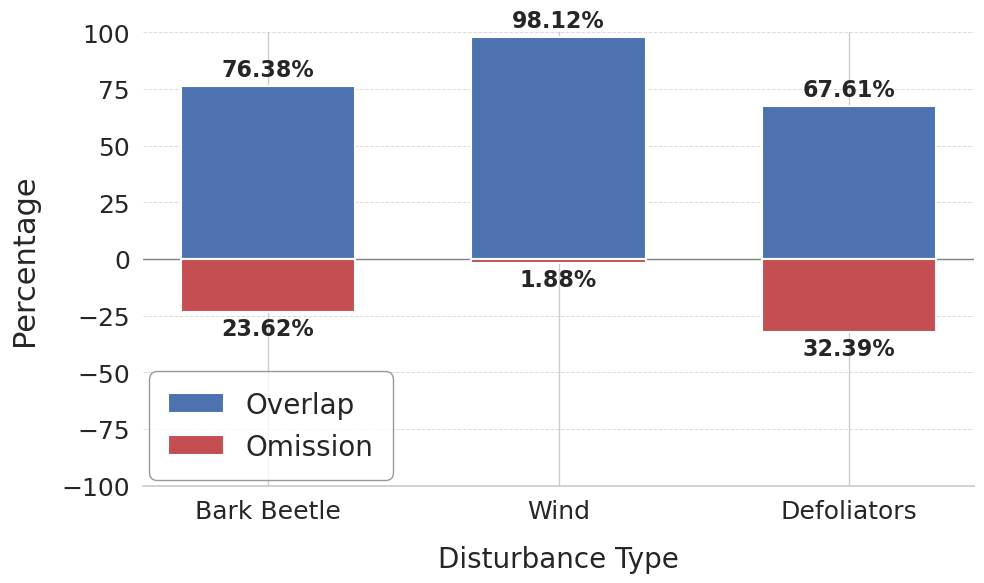

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Compute overlap and omission per disturbance type ---
types_order = ['bark_beetle', 'wind', 'defoliators']
labels_pretty = ['Bark Beetle', 'Wind', 'Defoliators']

overlap_list = []
omission_list = []

for dtype in types_order:
    subset = merged[merged['DCA_ID_IDS'] == dtype]
    total = len(subset)
    overlap = (subset['DCA_ID_S1DM'] == dtype).sum()
    omission = total - overlap
    overlap_pct = 100 * overlap / total
    omission_pct = -100 * omission / total  # negative for plotting below x-axis
    overlap_list.append(overlap_pct)
    omission_list.append(omission_pct)

# --- Plot ---
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.6
x = np.arange(len(labels_pretty))

# Use single, solid colors
overlap_color = "#4C72B0"   # blue
omission_color = "#C44E52"  # red

# Plot overlap bars
bars1 = ax.bar(
    x, overlap_list,
    color=overlap_color,
    width=bar_width,
    edgecolor='white',
    linewidth=1.5,
    label="Overlap",
    zorder=3
)

# Plot omission bars
bars2 = ax.bar(
    x, omission_list,
    color=omission_color,
    width=bar_width,
    edgecolor='white',
    linewidth=1.5,
    label="Omission",
    zorder=3
)

# Zero line
ax.axhline(0, color='gray', linewidth=1.0, zorder=2)

# Annotations
for i, (ov, om) in enumerate(zip(overlap_list, omission_list)):
    ax.text(i, ov + 2, f"{ov:.2f}%", ha='center', va='bottom', fontsize=16, fontweight='bold')
    ax.text(i, om - 2, f"{-om:.2f}%", ha='center', va='top', fontsize=16, fontweight='bold')

# Labels and ticks
ax.set_ylabel("Percentage", fontsize=22, labelpad=16)
ax.set_xlabel("Disturbance Type", fontsize=20, labelpad=16)
ax.set_xticks(x)
ax.set_xticklabels(labels_pretty, fontsize=18, fontweight='medium')
ax.tick_params(axis='y', labelsize=18)

# Grid and aesthetics
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7, zorder=0)
ax.set_ylim(-100, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Legend
legend = ax.legend(fontsize=20, frameon=True, edgecolor='gray', facecolor='white')
legend.get_frame().set_boxstyle('round,pad=0.3')

plt.tight_layout()
plt.show()
